<a href="https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/00_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TÖL506M - Introduction to Deep Neural Network
## Final Project: Wildlife Image Classification
### Data Exploration
**name:** Luiza V Sampaio Ramos, **email:** lvs2@gmail.com

In [1]:
# --- Colab setup for running notebooks with local package-style imports ---
#                 The code below, was generated by ChatGPT

# 1) Configure your repo details
REPO_URL = "https://github.com/LuizaRamos/TOL506M_Final_Project.git"
REPO_DIR = "/content/TOL506M_Final_Project"

# 2) Clone or update the repo
import os, sys, subprocess, pathlib

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    # pull latest; safe if you want current main
    subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only"], check=True)

# 3) Make the repo root the working directory
os.chdir(REPO_DIR)

# 4) Put the repo on PYTHONPATH so `from utils import ...` etc. works
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["PYTHONPATH"] = REPO_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

# 5) (Optional) install dependencies if you have a requirements.txt or pyproject
if os.path.exists("requirements.txt"):
    # quiet install
    subprocess.run(["pip", "install", "-q", "-r", "requirements.txt"], check=True)

In [2]:
# Imports
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import torch
from torchvision import datasets, transforms

# Setup
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

print(f'PyTorch version: {torch.__version__}\n')
print(f'CUDA available: {torch.cuda.is_available()}\n')

PyTorch version: 2.8.0+cu126

CUDA available: True



In [6]:
import kagglehub
import shutil

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

dst = "/content/TOL506M_Final_Project/data/animals10"

# Copy folder even if the destination already exists
shutil.copytree(path, dst, dirs_exist_ok=True)

print("Path to dataset files:", dst)

Path to dataset files: /content/TOL506M_Final_Project/data/animals10


In [7]:
DATA_PATH = dst

basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root=str(DATA_PATH), transform=basic_transform)

print(f'Total images: {len(dataset)}\n')
print(f'Classes: {dataset.classes}\n')

Total images: 26179

Classes: ['raw-img']



In [ ]:
# Class Distribution Analysis
labels = [label for _, label in dataset.imgs]
class_counts = Counter(labels)

percentages = {label: (count / len(labels)) * 100 for label, count in class_counts.items()}

# Sort by percentage in descending order
sorted_classes = sorted(percentages.items(), key=lambda x: x[1], reverse=True)

for label, percentages in sorted_classes:
    print(f"{percentages:.2f}% are {idx_to_english[label]} - {class_counts[label]} images")

18.58% are dog - 4863 images
18.42% are spider - 4821 images
11.83% are chicken - 3098 images
10.02% are horse - 2623 images
8.07% are butterfly - 2112 images
7.13% are cow - 1866 images
7.11% are squirrel - 1862 images
6.95% are sheep - 1820 images
6.37% are cat - 1668 images
5.52% are elephant - 1446 images


In [ ]:
imgs_per_class = np.zeros(num_classes)
for i in range(num_classes):
    imgs_per_class[i] = class_counts[i]

# Statistics:
print(f' Mean images per class: {np.mean(imgs_per_class):.2f}')
print(f' Std images per class: {np.std(imgs_per_class):.2f}')
print(f' Min images per class: {np.min(imgs_per_class):.0f}')
print(f' Max images per class: {np.max(imgs_per_class):.0f}')

 Mean images per class: 2617.90
 Std images per class: 1201.23
 Min images per class: 1446
 Max images per class: 4863


In [ ]:
# Analysing Image Dimensions
widths = []
heights = []
aspect_ratios = []

sample_indices = np.random.choice(len(dataset), size=1000, replace=False)

for idx in sample_indices:
    img_path, _ = dataset.imgs[idx]
    with Image.open(img_path) as img:
      w, h = img.size
      widths.append(w)
      heights.append(h)
      aspect_ratios.append(w / h)

print(f'Width: Mean {np.mean(widths):.2f}, Std {np.std(widths):.2f}, Min {np.min(widths):.0f}, Max {np.max(widths):.0f}')
print(f'Height: Mean {np.mean(heights):.2f}, Std {np.std(heights):.2f}, Min {np.min(widths):.0f}, Max {np.max(widths):.0f}')
print(f'Aspect Ratio: Mean {np.mean(aspect_ratios):.2f}, Std {np.std(aspect_ratios):.2f}, Min {np.min(aspect_ratios):.2f}, Max {np.max(aspect_ratios):.2f}')

Width: Mean 323.12, Std 226.97, Min 60, Max 4928
Height: Mean 256.51, Std 153.20, Min 60, Max 4928
Aspect Ratio: Mean 1.29, Std 0.30, Min 0.41, Max 2.34


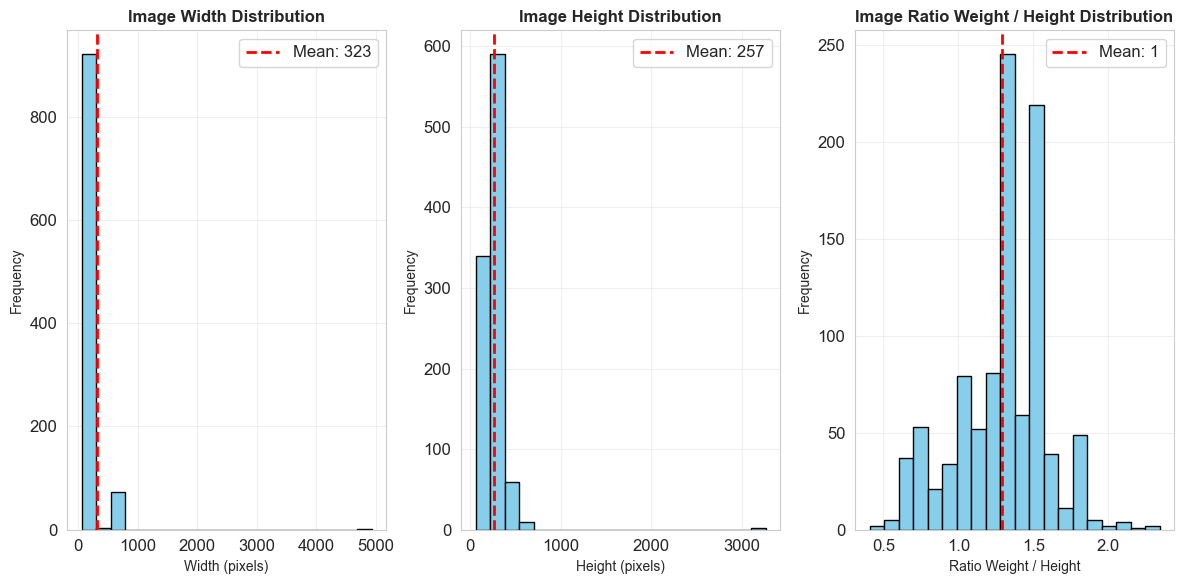

In [ ]:
# Visualization of the Image Size Distribution
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# Plot for Width
axes[0].hist(widths, bins=20, color='skyblue', edgecolor='black')
axes[0].axvline(np.mean(widths), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(widths):.0f}')
axes[0].set_xlabel('Width (pixels)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].set_title('Image Width Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot for Height
axes[1].hist(heights, bins=20, color='skyblue', edgecolor='black')
axes[1].axvline(np.mean(heights), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(heights):.0f}')
axes[1].set_xlabel('Height (pixels)', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].set_title('Image Height Distribution', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot for the Ratio (Weight / Height)
axes[2].hist(aspect_ratios, bins=20, color='skyblue', edgecolor='black')
axes[2].axvline(np.mean(aspect_ratios), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(aspect_ratios):.0f}')
axes[2].set_xlabel('Ratio Weight / Height', fontsize=10)
axes[2].set_ylabel('Frequency', fontsize=10)
axes[2].set_title('Image Ratio Weight / Height Distribution', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Data Split
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

print(f'Train size: {train_size}')
print(f'Validation size: {val_size}')
print(f'Test size: {test_size}')

Train size: 18325
Validation size: 3926
Test size: 3928
